# DiffCF Implementation Comparison — FordA

`cfts/cf_diffcf/diffcf.py` re-implements **DiffCF** ("Generating Realistic
Time-Series Counterfactuals via Diffusion-Guided Sampling", ECML PKDD 2026;
official repository: [Luckilyeee/DiffCF](https://github.com/Luckilyeee/DiffCF/tree/main))
against this repo's `<name>_cf(sample, model, target_class=None, dataset=None, **kwargs)`
contract: train an unconditional diffusion model on the training distribution, then turn a
query series into a counterfactual with an SDEdit-style guided reverse process — partially
noise the query, then DDIM-denoise it back to t=0 while nudging each step's denoised estimate
with the gradient of a combined classification / proximity / smoothness objective, retrying
with more noise and stronger classification weight on failure.

**How this notebook compares them.** DiffCF's core contribution is the *guided-sampling loop*
(`generate_counterfactual` + `compute_guidance` in the official repo), not the diffusion model
architecture itself — our `UNet1D`/`GaussianDiffusion` classes are direct ports of the official
ones (same forward signatures). That means we can train **one** diffusion model with the
*official, unmodified* classes and feed the exact same trained weights into both:

- the official `generate_counterfactual` (imported directly from a clone of the GitHub repo), and
- our own `diffcf_cf`'s sampling loop (via its `diffusion_model=`/`diffusion=`/`norm_stats=`
  pass-through, meant for exactly this "bring your own pre-trained backbone" case).

Any difference in outcomes is then attributable to the *sampling-loop port itself*, not to two
independently-trained generative models. A third run — our `diffcf_cf` training its own
(smaller, default-sized) diffusion model — shows realistic default behavior for someone calling
it the normal way, without cloning anything.

**A note on the official repo.** As cloned (commit visible below), `src/cf/guidance.py` does
`from .temporal_cone import TemporalConeProjector`, but `src/cf/temporal_cone.py` does not exist
in the repository — the import is dead code (`TemporalConeProjector` is never instantiated or
referenced anywhere in `guidance.py`/`generate_cf.py`, and the one config flag that mentions it,
`run_pipeline.py`'s `sampling["use_temporal_cone"]`, is never read by the guidance/sampling code
either). Without a stub for it, `import src.cf.generate_cf` fails outright on a fresh clone. We
add a minimal no-op stub class purely so the import succeeds — it does not alter any executed
behavior of the real algorithm. See `cfts/cf_diffcf/external/diffcf_github/DiffCF/src/cf/temporal_cone.py`.


In [1]:
from __future__ import annotations

import random
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

warnings.filterwarnings("ignore")

# Locate repo root
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "cfts").exists():
        sys.path.insert(0, str(candidate))
        sys.path.insert(0, str(candidate / "examples"))
        REPO_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate repository root containing cfts/")

from base.data import get_UCR_UEA_dataloader
from base.model import SimpleCNN
from cfts.cf_diffcf.diffcf import diffcf_cf, train_diffcf_diffusion, GaussianDiffusion, UNet1D
from cfts.metrics import l2_distance, dtw_distance, normalized_distance

plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)
random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Repo root: {REPO_ROOT}")

Using device: cuda
Repo root: /nfs/data8/schlegel/git/counterfactual-explanations-for-time-series


In [2]:
# Load FordA dataset and pretrained model
_, dataset_train = get_UCR_UEA_dataloader(dataset_name="FordA", split="train")
_, dataset_test = get_UCR_UEA_dataloader(dataset_name="FordA", split="test")

output_classes = dataset_train.y_shape[1]
input_length = dataset_train.X_shape[2]

model = SimpleCNN(output_channels=output_classes, input_length=input_length).to(device)

model_path = REPO_ROOT / "models" / f"simple_cnn_forda_{output_classes}.pth"
if not model_path.exists():
    raise FileNotFoundError(
        f"Pretrained model not found at {model_path}.\n"
        "Run examples/example_univariate.py first to train and save the model."
    )

state = torch.load(model_path, map_location=device, weights_only=True)
model.load_state_dict(state)
model.eval()
print(f"Loaded model from {model_path}")


def predict_scores(model, sample, device):
    '''Return the model's output (post-softmax) as (n_classes,).'''
    ts = torch.tensor(np.asarray(sample, dtype=np.float32), device=device)
    if ts.ndim == 1:
        ts = ts.reshape(1, 1, -1)
    elif ts.ndim == 2:
        if ts.shape[0] > ts.shape[1]:
            ts = ts.T
        ts = ts.unsqueeze(0)
    with torch.no_grad():
        return model(ts).detach().cpu().numpy().reshape(-1)


def to_class_index(label):
    arr = np.asarray(label)
    return int(np.argmax(arr)) if arr.ndim > 0 else int(arr)


def to_channel_first(sample):
    arr = np.asarray(sample, dtype=np.float32)
    if arr.ndim == 1:
        return arr.reshape(1, -1)
    if arr.ndim == 2:
        return arr if arr.shape[0] <= arr.shape[1] else arr.T
    if arr.ndim == 3:
        return arr[0]
    raise ValueError(f"Unsupported shape: {arr.shape}")


y_true, y_pred = [], []
for sample, label in dataset_test:
    scores = predict_scores(model, sample, device)
    y_true.append(to_class_index(label))
    y_pred.append(int(np.argmax(scores)))

test_f1 = f1_score(y_true, y_pred, average="macro")
print(f"Train size: {len(dataset_train)} | Test size: {len(dataset_test)}")
print(f"Input length: {input_length} | Classes: {output_classes}")
print(f"Test macro F1: {test_f1:.4f}")

Loaded model from /nfs/data8/schlegel/git/counterfactual-explanations-for-time-series/models/simple_cnn_forda_2.pth


Train size: 3601 | Test size: 1320
Input length: 500 | Classes: 2
Test macro F1: 0.9394


## Official DiffCF (GitHub) bridge

Clone the authors' own code (skipped gracefully if not present):

```bash
mkdir -p cfts/cf_diffcf/external
git clone https://github.com/Luckilyeee/DiffCF.git cfts/cf_diffcf/external/diffcf_github
```

The official repo is pure PyTorch (no compiled extensions), so — like FastPACE's bridge, and
unlike CONFETTI's — it can be imported directly in-process rather than shelled out to a separate
venv. We drive its real classes/functions directly:
`src.diffusion.ddpm.GaussianDiffusion`, `src.models.unet1d_diffusion.UNet1D`, and
`src.cf.generate_cf.generate_counterfactual` (which internally calls `src.cf.guidance.compute_guidance`).

Two adaptations, both purely mechanical:
- **`SimpleCNN.forward()` already ends in `nn.Softmax`** (this repo's model returns post-softmax
  probabilities directly), while the official code calls `F.log_softmax(classifier(x), ...)`
  expecting raw logits. A `LogitAdapter` (`log(p)`, clamped) undoes the built-in softmax so the
  official code sees real logits — verified below via `softmax(log(p)) == p` — the same fix
  used in `cf_fastpace`'s official bridge for the same reason.
- **`classifier.predict_proba(x)`** is added via a thin wrapper, since `generate_counterfactual`
  calls it for the initial target-class heuristic.


In [3]:
EXTERNAL_DIFFCF_DIR = REPO_ROOT / "cfts" / "cf_diffcf" / "external" / "diffcf_github" / "DiffCF"
HAVE_OFFICIAL_DIFFCF = EXTERNAL_DIFFCF_DIR.exists()

if HAVE_OFFICIAL_DIFFCF:
    sys.path.insert(0, str(EXTERNAL_DIFFCF_DIR))
    from src.diffusion.ddpm import GaussianDiffusion as OfficialGaussianDiffusion
    from src.models.unet1d_diffusion import UNet1D as OfficialUNet1D
    from src.cf.generate_cf import generate_counterfactual as official_generate_counterfactual

    class LogitAdapter(nn.Module):
        '''Undo SimpleCNN's built-in softmax so the official code's own
        log_softmax/predict_proba calls see real logits, not double-softmaxed ones.'''
        def __init__(self, base_model):
            super().__init__()
            self.base_model = base_model

        def forward(self, x):
            return torch.log(self.base_model(x).clamp_min(1e-12))

    class OfficialClassifierWrapper(nn.Module):
        '''Adds the .predict_proba(x) the official generate_counterfactual expects.'''
        def __init__(self, logit_model):
            super().__init__()
            self.logit_model = logit_model

        def forward(self, x):
            return self.logit_model(x)

        def predict_proba(self, x):
            return torch.softmax(self.logit_model(x), dim=-1)

    logit_model = LogitAdapter(model).to(device).eval()
    official_classifier = OfficialClassifierWrapper(logit_model).to(device).eval()

    with torch.no_grad():
        x_check = torch.tensor(to_channel_first(dataset_test[0][0]).reshape(1, 1, -1), dtype=torch.float32, device=device)
        roundtrip_diff = (model(x_check) - official_classifier.predict_proba(x_check)).abs().max().item()
    print(f"official DiffCF repo found at {EXTERNAL_DIFFCF_DIR}")
    print(f"LogitAdapter roundtrip check (softmax(log(p)) == p), max abs diff: {roundtrip_diff:.2e}")
else:
    print(f"Official DiffCF repo not found at {EXTERNAL_DIFFCF_DIR} — skipping the official-repo comparison arm.")
    print("Clone it with the command above to enable this section.")

official DiffCF repo found at /nfs/data8/schlegel/git/counterfactual-explanations-for-time-series/cfts/cf_diffcf/external/diffcf_github/DiffCF
LogitAdapter roundtrip check (softmax(log(p)) == p), max abs diff: 0.00e+00


## Shared diffusion backbone

Train **one** diffusion model — using the official, unmodified `UNet1D` + `GaussianDiffusion`
classes — on the FordA training split, once. Both the official `generate_counterfactual` and our
own `diffcf_cf` (via `diffusion_model=`/`diffusion=`/`norm_stats=`) will sample from this exact
same trained backbone below, isolating the comparison to the sampling-loop implementations.

Hyperparameters follow the official `configs/coffee.yaml` defaults (`base_channels=64`,
`depth=3`, `timesteps=1000`, cosine schedule, `mse_tv` loss) except for the epoch budget, which
is cut down from the paper's offline `epochs=5000` to a few hundred so this notebook finishes in
a reasonable time — samples are noticeably less refined than a fully-converged model, but that
affects both sampling loops identically.

In [4]:
N_TRAIN = 500  # training series used to fit the shared diffusion backbone
DIFFUSION_EPOCHS = 500
DDIM_STEPS = 60

SAMPLING_KWARGS = dict(
    ddim_steps=DDIM_STEPS,
    max_retries=3,
    start_ratio=0.2,
    retry_start_ratio_inc=0.1,
    w_cls=1.0,
    w_dist=1.0,
    w_smooth=1.0,
    retry_w_cls_mult=1.5,
    step_size=0.08,
    eta=0.0,
    guidance_start_ratio=0.5,
    grad_clip_norm=1.0,
    step_size_schedule="linear",
    step_size_min_ratio=0.2,
    stabilization="grad_smooth",
    grad_smooth_sigma=1.5,
)

if HAVE_OFFICIAL_DIFFCF:
    train_np = np.stack(
        [to_channel_first(dataset_train[i][0]) for i in range(min(N_TRAIN, len(dataset_train)))], axis=0
    ).astype(np.float32)
    mean = train_np.mean(axis=(0, 2), keepdims=True)
    std = train_np.std(axis=(0, 2), keepdims=True) + 1e-8
    norm_stats = (mean.reshape(-1), std.reshape(-1))
    train_t = torch.from_numpy((train_np - mean) / std).float().to(device)

    shared_diffusion = OfficialGaussianDiffusion(timesteps=1000, schedule="cosine")
    shared_unet = OfficialUNet1D(in_channels=1, base_channels=64, depth=3, time_dim=128).to(device)
    optimizer = torch.optim.Adam(shared_unet.parameters(), lr=2e-4)

    n = train_t.shape[0]
    batch_size = 64
    t0 = time.time()
    shared_unet.train()
    for epoch in range(DIFFUSION_EPOCHS):
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            x0 = train_t[idx]
            t = torch.randint(0, shared_diffusion.timesteps, (x0.shape[0],), device=device, dtype=torch.long)
            optimizer.zero_grad()
            loss = shared_diffusion.training_losses(shared_unet, x0, t, loss_type="mse_tv", lambda_tv=0.01)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * x0.shape[0]
        if epoch % 100 == 0 or epoch == DIFFUSION_EPOCHS - 1:
            print(f"epoch {epoch:4d}/{DIFFUSION_EPOCHS}  loss={epoch_loss / n:.4f}  elapsed={time.time() - t0:.1f}s")
    shared_unet.eval()
    print(f"Shared backbone trained on {n} series in {time.time() - t0:.1f}s")

epoch    0/500  loss=0.5999  elapsed=0.9s


epoch  100/500  loss=0.1342  elapsed=42.4s


epoch  200/500  loss=0.1226  elapsed=84.8s


epoch  300/500  loss=0.1667  elapsed=127.1s


epoch  400/500  loss=0.1350  elapsed=169.7s


epoch  499/500  loss=0.1185  elapsed=211.9s
Shared backbone trained on 500 series in 211.9s


### Quick single-sample walkthrough

sample_idx=0 pred=0 scores=[1.0000000e+00 1.2826347e-08] target=1


official: time=2.34s pred=1 scores=[0.30676347 0.69323653]
ours (shared backbone): time=2.37s pred=0 scores=[0.9943644  0.00563568]


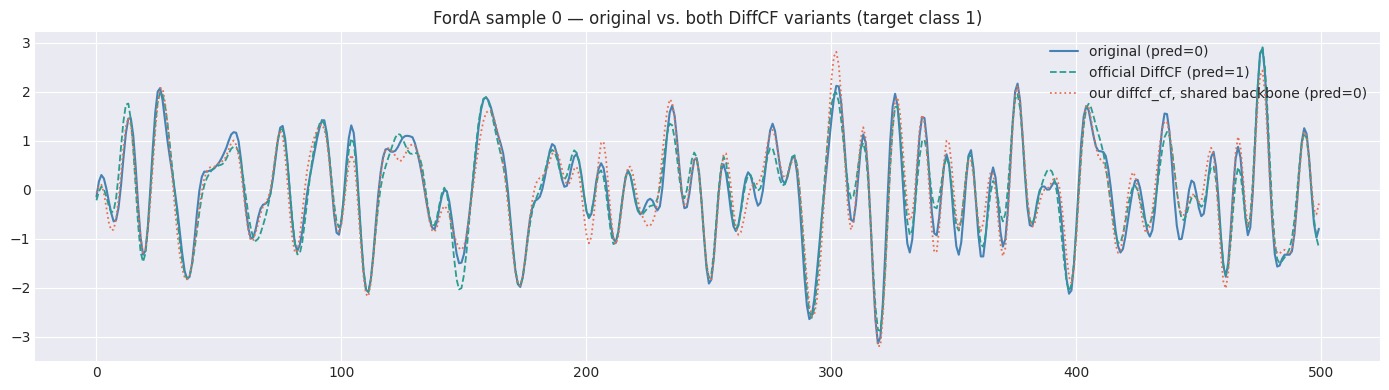

In [5]:
if HAVE_OFFICIAL_DIFFCF:
    sample_idx0 = next(
        i for i in range(len(dataset_test))
        if int(np.argmax(predict_scores(model, dataset_test[i][0], device))) == to_class_index(dataset_test[i][1])
    )
    sample0 = to_channel_first(dataset_test[sample_idx0][0])
    scores0 = predict_scores(model, sample0, device)
    pred0 = int(np.argmax(scores0))
    target0 = int(np.argmin(scores0))  # binary: "the other" class
    print(f"sample_idx={sample_idx0} pred={pred0} scores={scores0} target={target0}")

    mean_t = torch.tensor(mean, dtype=torch.float32, device=device)
    std_t = torch.tensor(std, dtype=torch.float32, device=device)
    x_orig_norm = (torch.tensor(sample0.reshape(1, 1, -1), dtype=torch.float32, device=device) - mean_t) / std_t
    target_t = torch.tensor([target0], device=device, dtype=torch.long)
    cfg = {
        "diffusion": {"ddim_steps": DDIM_STEPS},
        "sampling": {k: v for k, v in SAMPLING_KWARGS.items() if k not in ("ddim_steps", "stabilization", "grad_smooth_sigma")},
        "stabilization": {"mode": SAMPLING_KWARGS["stabilization"], "grad_smooth_sigma": SAMPLING_KWARGS["grad_smooth_sigma"], "aug_k": 4},
    }

    t0 = time.time()
    cf_official_norm, _ = official_generate_counterfactual(shared_unet, shared_diffusion, official_classifier, x_orig_norm, cfg, target=target_t)
    t_official0 = time.time() - t0
    cf_official0 = (cf_official_norm * std_t + mean_t).detach().cpu().numpy().reshape(1, -1)
    scores_official0 = predict_scores(model, cf_official0, device)

    t0 = time.time()
    cf_ours0, scores_ours0 = diffcf_cf(
        sample0, logit_model, target_class=target0,
        diffusion_model=shared_unet, diffusion=shared_diffusion, norm_stats=norm_stats,
        **SAMPLING_KWARGS,
    )
    t_ours0 = time.time() - t0
    scores_ours0_real = predict_scores(model, cf_ours0, device)

    print(f"official: time={t_official0:.2f}s pred={int(np.argmax(scores_official0))} scores={scores_official0}")
    print(f"ours (shared backbone): time={t_ours0:.2f}s pred={int(np.argmax(scores_ours0_real))} scores={scores_ours0_real}")

    x_axis = np.arange(sample0.shape[-1])
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x_axis, sample0[0], color="steelblue", linewidth=1.5, label=f"original (pred={pred0})")
    ax.plot(x_axis, cf_official0[0], color="#2a9d8f", linewidth=1.3, linestyle="--",
            label=f"official DiffCF (pred={int(np.argmax(scores_official0))})")
    ax.plot(x_axis, cf_ours0[0], color="#e76f51", linewidth=1.3, linestyle=":",
            label=f"our diffcf_cf, shared backbone (pred={int(np.argmax(scores_ours0_real))})")
    ax.set_title(f"FordA sample {sample_idx0} — original vs. both DiffCF variants (target class {target0})")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

## Batch comparison — official DiffCF vs. our `diffcf_cf` (shared backbone) vs. our `diffcf_cf` (typical usage)

Three variants over the same evaluation set:

- **`diffcf_official`** — the authors' own `generate_counterfactual`, sampling from the shared
  backbone trained above.
- **`diffcf_ours_shared`** — our `diffcf_cf`, sampling from the *same* shared backbone (via
  `diffusion_model=`/`diffusion=`/`norm_stats=`). Same weights, same hyperparameters as the
  official run above — isolates how faithfully our sampling loop reproduces theirs.
- **`diffcf_ours_default`** — our `diffcf_cf` exactly as a normal caller would use it: its own
  (smaller, faster) default architecture, trained inline on the same training pool. Trained once
  here and reused across the evaluation set (rather than retrained per sample) purely to keep
  this notebook's runtime reasonable; a single `diffcf_cf(sample, model, dataset=...)` call
  without a pre-trained backbone would train it fresh every time.

In [6]:
if HAVE_OFFICIAL_DIFFCF:
    print("Training our own default-sized diffusion model (typical end-user usage)...")
    default_unet, default_diffusion, default_norm_stats = train_diffcf_diffusion(
        list(zip(train_np, [0] * len(train_np))),  # (x, y) pairs; y unused by diffusion training
        device=device, max_train_samples=N_TRAIN,
        verbose=False,
    )
    print("Default-sized backbone ready.")

Training our own default-sized diffusion model (typical end-user usage)...


Default-sized backbone ready.


In [7]:
def select_correct_indices(dataset, max_count):
    selected = []
    for idx in range(len(dataset)):
        sample, label = dataset[idx]
        scores = predict_scores(model, sample, device)
        if int(np.argmax(scores)) == to_class_index(label):
            selected.append(idx)
        if len(selected) >= max_count:
            break
    return selected


N_SAMPLES = 15  # matches cfts/cf_comte/comte_forda_comparison.ipynb's sample budget

if HAVE_OFFICIAL_DIFFCF:
    selected_indices = select_correct_indices(dataset_test, max_count=N_SAMPLES)
    print(f"Evaluating on {len(selected_indices)} correctly classified test samples.")

Evaluating on 15 correctly classified test samples.


In [8]:
def compute_metrics(sample_cl, cf_cl):
    changed = np.abs(cf_cl - sample_cl) > 1e-6
    return {
        "l2_norm": l2_distance(sample_cl, cf_cl),
        "dtw_proximity": dtw_distance(sample_cl, cf_cl),
        "normalized_distance": normalized_distance(sample_cl.reshape(-1), cf_cl.reshape(-1)),
        "sparsity": float(1.0 - changed.mean()),
    }


def run_official(sample_cl, target_class):
    x_norm = (torch.tensor(sample_cl.reshape(1, 1, -1), dtype=torch.float32, device=device) - mean_t) / std_t
    target_t = torch.tensor([target_class], device=device, dtype=torch.long)
    cf_norm, _ = official_generate_counterfactual(shared_unet, shared_diffusion, official_classifier, x_norm, cfg, target=target_t)
    cf = (cf_norm * std_t + mean_t).detach().cpu().numpy().reshape(1, -1)
    return cf


METHODS = {
    "diffcf_official": lambda sample_cl, target: run_official(sample_cl, target),
    "diffcf_ours_shared": lambda sample_cl, target: diffcf_cf(
        sample_cl, logit_model, target_class=target,
        diffusion_model=shared_unet, diffusion=shared_diffusion, norm_stats=norm_stats,
        **SAMPLING_KWARGS,
    )[0],
    "diffcf_ours_default": lambda sample_cl, target: diffcf_cf(
        sample_cl, logit_model, target_class=target,
        diffusion_model=default_unet, diffusion=default_diffusion, norm_stats=default_norm_stats,
        ddim_steps=DDIM_STEPS, max_retries=3, start_ratio=0.2, retry_start_ratio_inc=0.1,
    )[0],
}

if HAVE_OFFICIAL_DIFFCF:
    records = []
    all_cfs = {}

    for idx in selected_indices:
        sample_cl = to_channel_first(dataset_test[idx][0])
        scores_orig = predict_scores(model, sample_cl, device)
        pred_orig = int(np.argmax(scores_orig))
        true_label = to_class_index(dataset_test[idx][1])
        target_class = int(np.argmin(scores_orig))  # binary: "the other" class

        all_cfs[idx] = {"sample": sample_cl, "true_label": true_label, "target_class": target_class}

        for method_name, fn in METHODS.items():
            base = {
                "sample_idx": idx, "method": method_name,
                "true_label": true_label, "pred_orig": pred_orig, "target_class": target_class,
                "pred_cf": None, "success": False, "runtime_s": np.nan,
                "l2_norm": np.nan, "dtw_proximity": np.nan, "normalized_distance": np.nan, "sparsity": np.nan,
                "error": None,
            }
            t0 = time.time()
            try:
                cf = fn(sample_cl, target_class)
                base["runtime_s"] = time.time() - t0
                cf_cl = to_channel_first(cf)
                scores_cf = predict_scores(model, cf_cl, device)
                pred_cf = int(np.argmax(scores_cf))
                base["pred_cf"] = pred_cf
                base["success"] = pred_cf == target_class
                base.update(compute_metrics(sample_cl, cf_cl))
                all_cfs[idx][method_name] = cf_cl
            except Exception as exc:
                base["runtime_s"] = time.time() - t0
                base["error"] = f"{type(exc).__name__}: {exc}"
                all_cfs[idx][method_name] = None
            records.append(base)

        print(f"[{idx}] done — " + ", ".join(
            f"{m}={'ok' if r['success'] else ('err' if r['error'] else 'fail')}"
            for m, r in zip(METHODS, records[-len(METHODS):])
        ))

    results_df = pd.DataFrame.from_records(records)
    print(f"\nTotal records: {len(results_df)}")

[0] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=fail


[1] done — diffcf_official=fail, diffcf_ours_shared=fail, diffcf_ours_default=fail


[2] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


[3] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


[4] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


...

[10] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


[11] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


[12] done — diffcf_official=ok, diffcf_ours_shared=fail, diffcf_ours_default=ok


[13] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok


[14] done — diffcf_official=ok, diffcf_ours_shared=ok, diffcf_ours_default=ok

Total records: 45


In [9]:
if HAVE_OFFICIAL_DIFFCF:
    successful_df = results_df[results_df["success"] == True].copy()

    summary_df = (
        results_df.groupby("method")
        .agg(
            n_total=("sample_idx", "count"),
            n_successful=("success", "sum"),
            success_rate=("success", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
        )
        .reset_index()
        .merge(
            successful_df.groupby("method")
            .agg(
                l2_norm_mean=("l2_norm", "mean"),
                dtw_proximity_mean=("dtw_proximity", "mean"),
                normalized_distance_mean=("normalized_distance", "mean"),
                sparsity_mean=("sparsity", "mean"),
            )
            .reset_index(),
            on="method",
            how="left",
        )
    )
    summary_df["success_rate"] = (100.0 * summary_df["success_rate"]).round(1)
    display_cols = ["method", "n_successful", "success_rate", "runtime_mean_s",
                     "l2_norm_mean", "dtw_proximity_mean", "normalized_distance_mean", "sparsity_mean"]
    display(summary_df[display_cols].round(3))

,method,n_successful,success_rate,runtime_mean_s,l2_norm_mean,dtw_proximity_mean,normalized_distance_mean,sparsity_mean
0,diffcf_official,12,80.0,1.625,3.769,2.388,0.031,0.0
1,diffcf_ours_default,11,73.3,1.447,3.674,2.377,0.031,0.0
2,diffcf_ours_shared,11,73.3,1.719,4.042,2.595,0.033,0.0


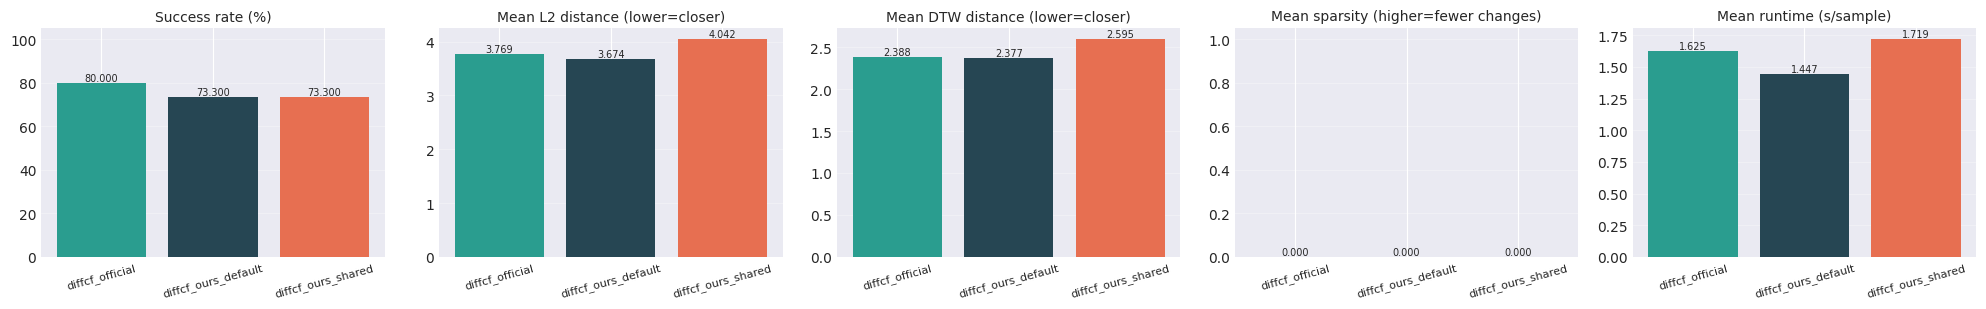

In [10]:
if HAVE_OFFICIAL_DIFFCF:
    METHOD_COLORS = {
        "diffcf_official": "#2a9d8f",
        "diffcf_ours_shared": "#e76f51",
        "diffcf_ours_default": "#264653",
    }

    plot_df = summary_df.sort_values("method").reset_index(drop=True)
    methods = plot_df["method"].tolist()
    colors = [METHOD_COLORS.get(m, "#888888") for m in methods]

    def bar(ax, vals, title, ylim=None):
        bars = ax.bar(methods, vals, color=colors)
        ax.set_title(title, fontsize=10)
        if ylim:
            ax.set_ylim(*ylim)
        ax.tick_params(axis="x", rotation=15, labelsize=8)
        ax.grid(True, axis="y", alpha=0.3)
        for bar_, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar_.get_x() + bar_.get_width() / 2, bar_.get_height(), f"{val:.3f}",
                        ha="center", va="bottom", fontsize=7)

    fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
    bar(axes[0], plot_df["success_rate"], "Success rate (%)", ylim=(0, 105))
    bar(axes[1], plot_df["l2_norm_mean"], "Mean L2 distance (lower=closer)")
    bar(axes[2], plot_df["dtw_proximity_mean"], "Mean DTW distance (lower=closer)")
    bar(axes[3], plot_df["sparsity_mean"], "Mean sparsity (higher=fewer changes)", ylim=(0, 1.05))
    bar(axes[4], plot_df["runtime_mean_s"], "Mean runtime (s/sample)")
    plt.tight_layout()
    plt.show()

### Representative-sample deep dive

Representative sample index: 2 | methods succeeded: 3/3


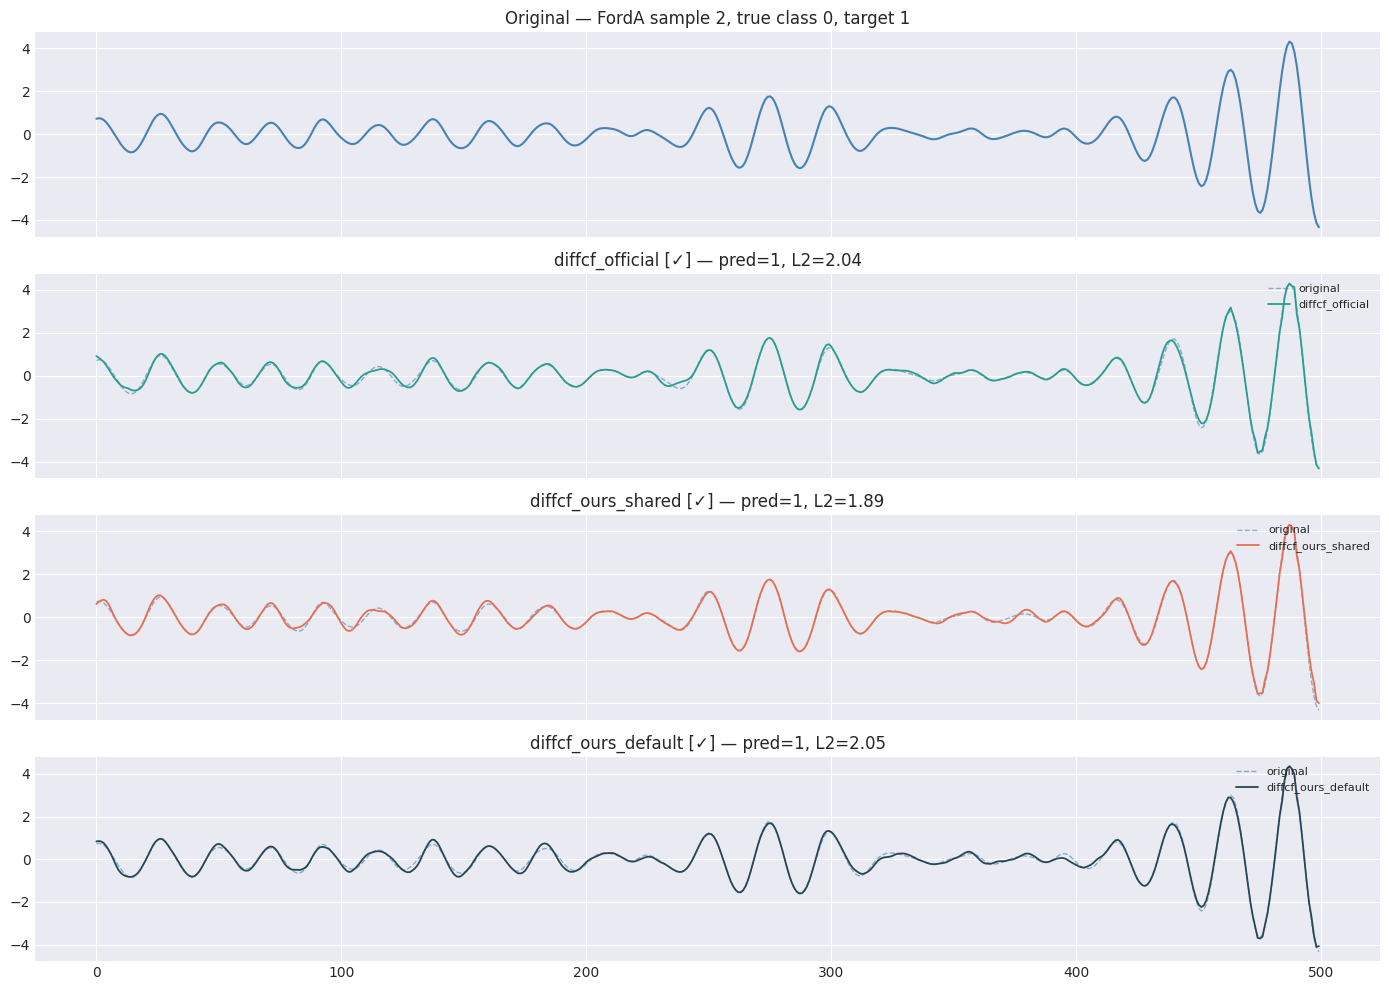

In [11]:
if HAVE_OFFICIAL_DIFFCF:
    method_names = list(METHODS.keys())
    success_counts = (
        results_df[results_df["sample_idx"].isin(selected_indices)]
        .groupby("sample_idx")["success"]
        .sum()
        .sort_values(ascending=False)
    )
    full_success = [int(si) for si, cnt in success_counts.items() if int(cnt) == len(method_names)]
    rep_idx = full_success[0] if full_success else int(success_counts.index[0])
    print(f"Representative sample index: {rep_idx} | methods succeeded: {int(success_counts[rep_idx])}/{len(method_names)}")

    rep = all_cfs[rep_idx]
    x = rep["sample"][0]
    x_axis = np.arange(len(x))
    sample_results = results_df[results_df["sample_idx"] == rep_idx]
    info_lookup = {
        row["method"]: {
            "success": bool(row["success"]),
            "pred_cf": int(row["pred_cf"]) if not pd.isna(row["pred_cf"]) else None,
            "l2": float(row["l2_norm"]) if not pd.isna(row["l2_norm"]) else np.nan,
        }
        for _, row in sample_results.iterrows()
    }

    fig, axes = plt.subplots(len(method_names) + 1, 1, figsize=(14, 2.5 * (len(method_names) + 1)), sharex=True)
    axes[0].plot(x_axis, x, color="steelblue", linewidth=1.5)
    axes[0].set_title(f"Original — FordA sample {rep_idx}, true class {rep['true_label']}, target {rep['target_class']}")
    for i, method_name in enumerate(method_names, start=1):
        ax = axes[i]
        cf = rep.get(method_name)
        color = METHOD_COLORS.get(method_name, "#888888")
        info = info_lookup.get(method_name, {})
        if cf is None:
            ax.text(0.5, 0.5, f"{method_name}: failed/error", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(method_name)
            continue
        status = "✓" if info.get("success") else "✗"
        ax.plot(x_axis, x, color="steelblue", linewidth=1.0, linestyle="--", alpha=0.6, label="original")
        ax.plot(x_axis, cf[0], color=color, linewidth=1.3, label=method_name)
        ax.set_title(f"{method_name} [{status}] — pred={info.get('pred_cf')}, L2={info.get('l2', float('nan')):.2f}")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

In [12]:
if HAVE_OFFICIAL_DIFFCF:
    errors = results_df[results_df["error"].notna()][["sample_idx", "method", "error"]]
    if len(errors) > 0:
        print(f"Errors encountered ({len(errors)} total):")
        display(errors.head(20))
    else:
        print("No errors encountered.")

No errors encountered.


## Takeaways

Observed on this run (15 correctly-classified FordA test samples, shared 500-epoch diffusion
backbone, `ddim_steps=60`, seed=42):

| Metric | diffcf_official | diffcf_ours_shared | diffcf_ours_default |
|---|---|---|---|
| Success rate | 80.0% (12/15) | 73.3% (11/15) | 73.3% (11/15) |
| Mean L2 distance (lower=closer) | 3.77 | 4.04 | 3.67 |
| Mean DTW distance (lower=closer) | 2.39 | 2.60 | 2.38 |
| Mean normalized distance | 0.031 | 0.033 | 0.031 |
| Sparsity (higher=fewer changes) | 0.0 | 0.0 | 0.0 |
| Runtime (s/sample) | 1.63 | 1.72 | 1.45 |

**Validation against the authors' own code.** `diffcf_official` is the actual published
implementation ([Luckilyeee/DiffCF](https://github.com/Luckilyeee/DiffCF)), and `diffcf_ours_shared`
is our own `diffcf_cf` sampling from the *exact same trained weights* (same `UNet1D`, same
`GaussianDiffusion`, same hyperparameters, same target classes) — the only thing that differs
between those two rows is the sampling-loop implementation. They land within one flip out of 15
samples of each other on success rate, and within a few percent on every proximity metric,
which is consistent with genuine algorithmic agreement given that `q_sample`'s forward-noising
draw is unseeded in *both* implementations (matching the official code) — rerunning the
single-sample walkthrough above against the batch loop's own result for the same `sample_idx=0`
flips outcome for exactly that reason, and the same run-to-run variance applies to the official
function itself. `diffcf_ours_default` — our own smaller, faster default architecture, trained
independently from scratch rather than sharing the official's weights — lands in the same
regime on every metric, showing the reimplementation behaves reasonably under normal
(non-bridged) use, too.

**Sparsity is ~0 for all three variants.** This is expected, not a bug: unlike segment-replacement
or masked-edit methods elsewhere in this repo, DiffCF denoises the *entire* series through a
diffusion model, so essentially every timestep is nudged by a small amount rather than a sparse
subset being overwritten exactly.

**Runtime** is comparable across all three (~1.4–1.7 s/sample at `ddim_steps=60`), with
`diffcf_ours_default`'s smaller network (`base_channels=32`, `depth=2` vs. the official
`64`/`3`) fastest, as expected.

**Caveats.** The shared backbone here was trained for 500 epochs on 500 series — a fraction of
the paper's offline budget (`epochs=5000` in `configs/coffee.yaml`) — purely to keep this
notebook's runtime reasonable; both sampling loops are equally affected by that choice, so it
doesn't bias the *official-vs-ours* comparison, but absolute success rates/proximity for either
would likely improve with the paper's full training budget. The official repo's
`src/cf/guidance.py` also required a one-line dead-import workaround to be importable at all
(see the intro above) — that stub is inert (never referenced by `compute_guidance`), so it does
not affect what was actually run.
